# Interpretative Jury Learning

Adjust **`RunConfig`** below, run **`run_full_pipeline(cfg)`**, then read metrics from **`result`**:

- **Training / validation (per epoch):** `result.training_metrics_df()` — columns include `train_loss`, `train_accuracy`, `val_loss`, `val_accuracy`, `learning_rate`.
- **Last epoch only:** `result.final_training_metrics()` — dict with the same fields.
- **Held-out test splits:** `result.eval_metrics_df()` or `result.eval_accuracy_by_split` — accuracies are fractions in `[0, 1]` (`validation` is the same val set used during training).

Set `cfg.verbose = False` for quiet runs; `cfg.show_progress_bar = True` for tqdm over batches.

**Optional plots** (continent breakdown, calibration, etc.) live in `jury_learning.plots`; see the section at the bottom.


In [1]:
!git clone "https://github.com/EmiDi3/Interpretative-Jury-Learning.git"
%cd Interpretative-Jury-Learning/

Cloning into 'Interpretative-Jury-Learning'...
remote: Enumerating objects: 58, done.
remote: Counting objects: 100% (58/58), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 58 (delta 28), reused 48 (delta 18), pack-reused 0 (from 0)
Receiving objects: 100% (58/58), 40.65 KiB | 6.77 MiB/s, done.
Resolving deltas: 100% (28/28), done.
/content/Interpretative-Jury-Learning


### Google Colab: Moral Machine zip on Google Drive

Optional. Mount Drive and extract `moral_machine.zip` into the Colab runtime (fast local disk). Adjust **`ZIP_PATH`** if your Drive folder layout differs. Skip this block when you already have `moral_machine.db` on local disk or next to the repo.

After extraction, the next cell sets **`cfg.db_path`** from **`MORAL_MACHINE_DB`** (defaulting to `moral_machine.db` if you skip this section).

In [4]:
import zipfile
from pathlib import Path

# Adjust paths if your Drive folder layout differs
ZIP_PATH              = Path("/content/drive/My Drive/Interpretative Jury Learning/moral_machine.zip")
SCENARIOS_DRIVE_PATH  = Path("/content/drive/My Drive/Interpretative Jury Learning/unique_scenarios.csv")
EXTRACT_PATH          = Path("/content")

try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    pass  # not on Colab

# Extract moral_machine.db from zip
if ZIP_PATH.is_file():
    EXTRACT_PATH.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print(f"Extracted {ZIP_PATH} -> {EXTRACT_PATH}")
    MORAL_MACHINE_DB = str(EXTRACT_PATH / "moral_machine.db")
else:
    print(f"No zip at {ZIP_PATH}; will use ./moral_machine.db")

# Copy unique_scenarios.csv from Drive to local disk (fast I/O)
if SCENARIOS_DRIVE_PATH.is_file():
    import shutil
    LOCAL_SCENARIOS = str(EXTRACT_PATH / "unique_scenarios.csv")
    shutil.copy(SCENARIOS_DRIVE_PATH, LOCAL_SCENARIOS)
    print(f"Copied unique_scenarios.csv -> {LOCAL_SCENARIOS}")
    UNIQUE_SCENARIOS_CSV = LOCAL_SCENARIOS
else:
    print(f"No unique_scenarios.csv at {SCENARIOS_DRIVE_PATH}; will use ./unique_scenarios.csv")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracted /content/drive/My Drive/Interpretative Jury Learning/moral_machine.zip -> /content


### Best Model Training

Trains the model with the best hyperparameters found by Optuna (trial #19, val_accuracy=0.7488) for 100 epochs. After every epoch the model is evaluated on the validation set and all held-out splits (new users, new scenarios, new groups, combined).

In [ ]:
from jury_learning import RunConfig, run_full_pipeline

cfg = RunConfig()

# Colab: after the Drive zip cell, this picks up MORAL_MACHINE_DB; locally defaults to ./moral_machine.db
cfg.db_path        = globals().get("MORAL_MACHINE_DB", "moral_machine.db")
cfg.scenarios_csv  = globals().get("UNIQUE_SCENARIOS_CSV", "unique_scenarios.csv")
cfg.model_path = "moral_jury_dcn_model.pth"

cfg.sql_subset_size = None  # None = full dataset
cfg.batch_size = 1024  # matches scale Optuna HPs were tuned at
cfg.eval_batch_size = 64

# Best hyperparameters from Optuna search (trial #19, val_accuracy=0.7488)
# lr scaled down from 0.009 to 0.001: Optuna ran on 100k rows (~390 batches/epoch);
# full dataset at batch_size=1024 gives ~4100 batches/epoch — same order of magnitude.
cfg.embed_dim = 64
cfg.hidden_dim = 512
cfg.num_cross_layers = 4
cfg.response_encoder_hidden = 32

cfg.epochs = 100
cfg.lr = 0.001
cfg.lr_phase2 = 7.279973631756403e-05
cfg.freeze_encoder_epoch_fraction = 0.5069047727472471

cfg.verbose = True
cfg.show_progress_bar = False
cfg.use_wandb = False

cfg.device = "auto"

cfg.run_training_stage = True
cfg.run_evaluation_stage = True

result = run_full_pipeline(cfg)


### Training Metrics

`result.training_metrics_df()` returns one row per epoch with columns:
`train_loss`, `train_accuracy`, `val_loss`, `val_accuracy`,
`new_users_accuracy`, `new_scenarios_accuracy`, `new_groups_accuracy`, `combined_accuracy`, `learning_rate`.

In [6]:
# Per-epoch metrics across all splits
result.training_metrics_df()


In [7]:
# Final epoch summary
result.final_training_metrics()


{'epoch': 50,
 'train_loss': 0.00806620888622655,
 'train_accuracy': 0.9999291466899696,
 'val_loss': 4.755688786506653,
 'val_accuracy': 0.7132343101833266,
 'learning_rate': 0.0001}

In [8]:
# Accuracy on validation + stress-test splits (fractions 0–1)
result.eval_metrics_df()


,split,accuracy
0,validation,0.713234
1,new_users,0.703184
2,new_scenarios,0.727975
3,new_groups,0.697330
4,combined,0.725934


### Hyperparameter Search

Uses **Optuna** (TPE sampler) to search over model size and training knobs. Data is loaded once and shared across all trials.

Tune **`N_TRIALS`** and **`TRIAL_EPOCHS`** below — fewer epochs per trial speeds up the search at the cost of accuracy. After the study completes, the best config is printed and you can paste those values back into the `RunConfig` above for a full training run.

In [ ]:
!pip install -q optuna

In [ ]:
import optuna
from optuna.samplers import TPESampler
from pathlib import Path

from jury_learning.config import RunConfig
from jury_learning.data import build_data_bundle
from jury_learning.pipeline import run_training

# --- Configure the search ---
N_TRIALS = 30
TRIAL_EPOCHS = 20  # fewer than full training epochs; speeds up the search

# Data settings — edit to match your setup
_search_cfg = RunConfig()
_search_cfg.db_path = globals().get("MORAL_MACHINE_DB", "moral_machine.db")
_search_cfg.sql_subset_size = None  # None = full dataset

optuna.logging.set_verbosity(optuna.logging.WARNING)

_EMBED_DIMS = [32, 64, 128, 256]
_HIDDEN_DIMS = [128, 256, 512, 1024]
_RESPONSE_ENCODER_HIDDENS = [32, 64, 128]
_BATCH_SIZES = [256, 512, 1024, 2048]

def _trial_cfg(trial, base_cfg):
    return RunConfig(
        db_path=base_cfg.db_path,
        scenarios_csv=base_cfg.scenarios_csv,
        sql_subset_size=base_cfg.sql_subset_size,
        eval_batch_size=base_cfg.eval_batch_size,
        random_seed=base_cfg.random_seed,
        new_users_holdout_fraction=base_cfg.new_users_holdout_fraction,
        new_groups_holdout_fraction=base_cfg.new_groups_holdout_fraction,
        val_fraction=base_cfg.val_fraction,
        rare_scenario_columns=base_cfg.rare_scenario_columns,
        device=base_cfg.device,
        embed_dim=trial.suggest_categorical("embed_dim", _EMBED_DIMS),
        hidden_dim=trial.suggest_categorical("hidden_dim", _HIDDEN_DIMS),
        num_cross_layers=trial.suggest_int("num_cross_layers", 1, 5),
        response_encoder_hidden=trial.suggest_categorical("response_encoder_hidden", _RESPONSE_ENCODER_HIDDENS),
        batch_size=trial.suggest_categorical("batch_size", _BATCH_SIZES),
        epochs=TRIAL_EPOCHS,
        lr=trial.suggest_float("lr", 1e-4, 1e-2, log=True),
        lr_phase2=trial.suggest_float("lr_phase2", 1e-5, 1e-3, log=True),
        freeze_encoder_epoch_fraction=trial.suggest_float("freeze_encoder_epoch_fraction", 0.3, 0.8),
        model_path=f"/tmp/hp_trial_{trial.number}.pth",
        verbose=False,
        show_progress_bar=False,
        use_wandb=False,
        run_training_stage=True,
        run_evaluation_stage=False,
    )

# Load data once, shared across all trials
print("Loading data...")
_bundle = build_data_bundle(_search_cfg)

def objective(trial):
    tcfg = _trial_cfg(trial, _search_cfg)
    try:
        _, _, history = run_training(tcfg, _bundle)
    except Exception as e:
        print(f"  Trial {trial.number} failed: {e}")
        raise optuna.exceptions.TrialPruned()
    finally:
        Path(tcfg.model_path).unlink(missing_ok=True)

    val_acc = history.last().get("val_accuracy", 0.0)
    print(
        f"  Trial {trial.number:3d} | val_acc={val_acc:.4f} | "
        f"embed={tcfg.embed_dim} hidden={tcfg.hidden_dim} cross={tcfg.num_cross_layers} "
        f"reh={tcfg.response_encoder_hidden} lr={tcfg.lr:.2e} bs={tcfg.batch_size} "
        f"freeze={tcfg.freeze_encoder_epoch_fraction:.2f}"
    )
    return val_acc

study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=_search_cfg.random_seed))
print(f"\nRunning {N_TRIALS} trials × {TRIAL_EPOCHS} epochs each...\n")
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

best = study.best_trial
print(f"\nBest trial #{best.number}  val_accuracy={best.value:.4f}")
print("Best hyperparameters:")
for k, v in best.params.items():
    print(f"  {k}: {v}")

In [ ]:
import importlib.util as _ilu
from pathlib import Path

_spec = _ilu.spec_from_file_location("llm_scenario_prompts", Path("06_llm_scenario_prompts.py").resolve())
_mod  = _ilu.module_from_spec(_spec); _spec.loader.exec_module(_mod)

df_prompts = _mod.build_prompt_dataset(
    input_path=globals().get("UNIQUE_SCENARIOS_CSV", "unique_scenarios.csv"),
    n=10_000,
    seed=42,
    db_path=globals().get("MORAL_MACHINE_DB", "moral_machine.db"),
)
df_prompts[["scenario_id", "prompt"]].to_csv("llm_prompts.csv", index=False)
print(f"Saved {len(df_prompts):,} prompts to llm_prompts.csv")
print("\nExample:")
print(df_prompts.loc[0, "prompt"])


### Transformer Model (arXiv:2602.03351)

Scenario-only Transformer encoder replicating the architecture from
*"Building Interpretable Models for Moral Decision-Making"* (2026).
Reaches 77% on their benchmark without using user IDs or demographics.

Each character column (Man, Woman, Dog, …) for Stay and Swerve becomes
one token: `e = [E_char ; E_card ; E_team]`. A `[CLS]` token feeds
a 2-layer GELU MLP head. Symmetric eval averages `f(A,B)` and `1−f(B,A)`.

Run this cell **instead of** the Best Model Training cell above if you want
to compare architectures.

In [ ]:
from jury_learning import RunConfig, run_full_pipeline

cfg_t = RunConfig()
cfg_t.db_path       = globals().get("MORAL_MACHINE_DB", "moral_machine.db")
cfg_t.scenarios_csv = globals().get("UNIQUE_SCENARIOS_CSV", "unique_scenarios.csv")
cfg_t.model_path    = "moral_jury_transformer.pth"

cfg_t.sql_subset_size = None
cfg_t.batch_size      = 1024
cfg_t.eval_batch_size = 256

# Transformer architecture (arXiv:2602.03351)
cfg_t.model_type           = "transformer"
cfg_t.transformer_d_model  = 64   # d_char=32, d_card=16, d_team=16
cfg_t.transformer_heads    = 2
cfg_t.transformer_layers   = 2
cfg_t.transformer_ff_dim   = 256
cfg_t.transformer_dropout  = 0.1
cfg_t.transformer_symmetric = True  # symmetric eval at inference

cfg_t.epochs       = 50
cfg_t.lr           = 1e-3
cfg_t.lr_phase2    = 1e-4
cfg_t.freeze_encoder_epoch_fraction = 2/3  # freezes response_encoder (no-op for transformer)
cfg_t.grad_clip_norm = 1.0

cfg_t.verbose           = True
cfg_t.show_progress_bar = False
cfg_t.use_wandb         = False
cfg_t.device            = "auto"
cfg_t.run_training_stage   = True
cfg_t.run_evaluation_stage = True

result_t = run_full_pipeline(cfg_t)
print("\nTransformer training metrics:")
result_t.training_metrics_df()


### Optional evaluation plots

Requires **`pip install matplotlib`**; continent aggregation needs **`pip install pycountry_convert`**.

- **`run_evaluation_plots`** — split bar chart, training curves, calibration diagram, continent + country bars (validation and new-user splits).
- Use **`accuracy_by_country`** + **`continent_metrics_table`** / **`country_metrics_table`** if you want tables without plotting.


In [10]:
!pip install pycountry_convert

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.2/254.2 kB 15.9 MB/s eta 0:00:00


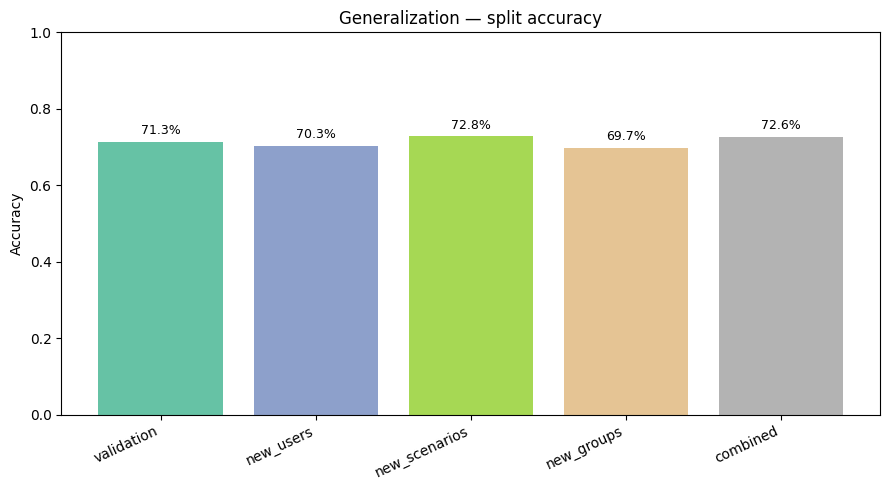

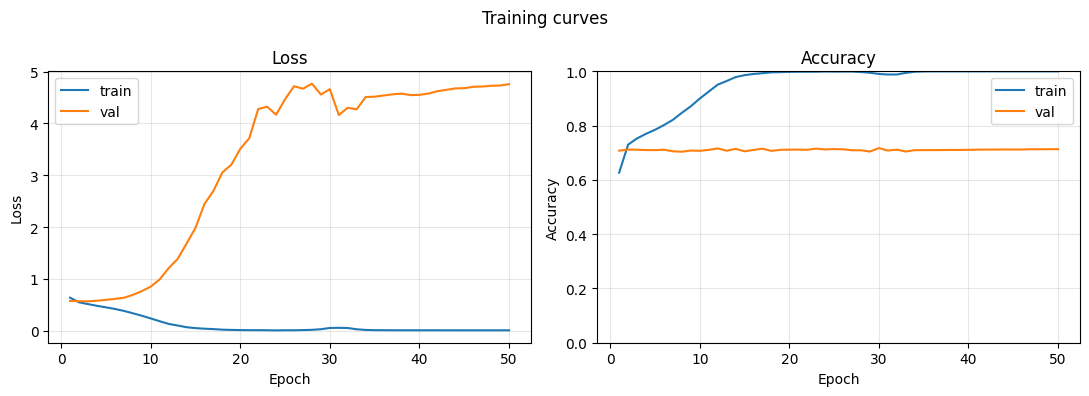

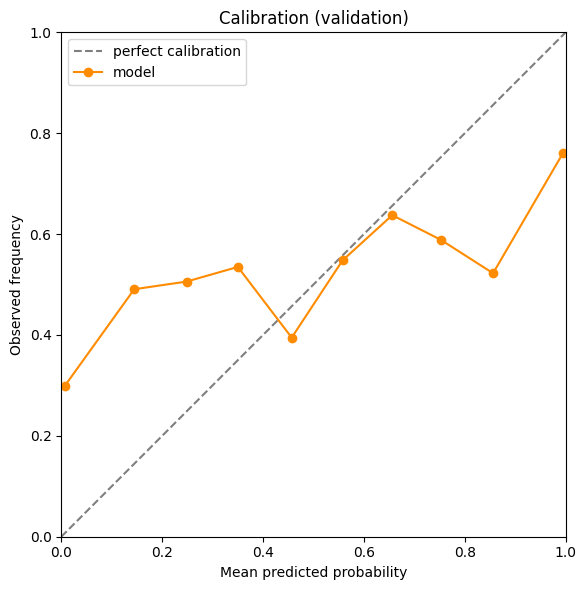

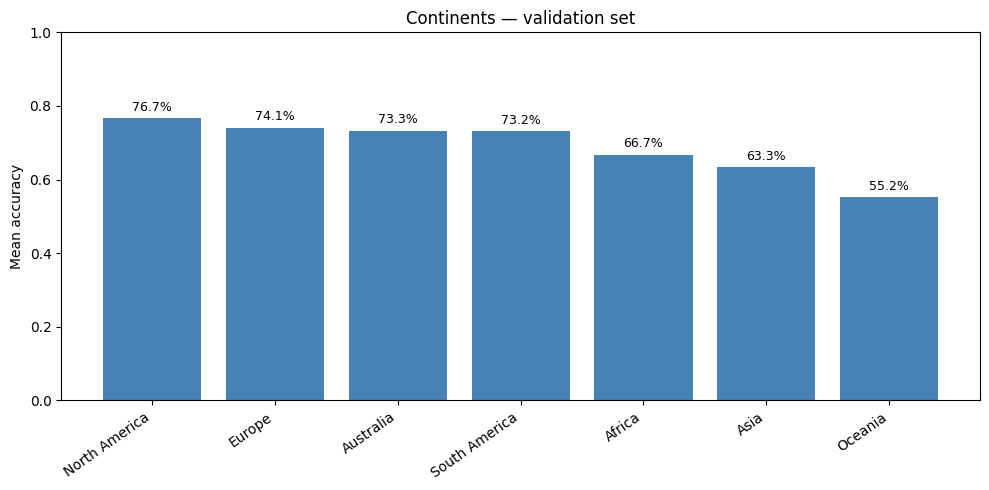

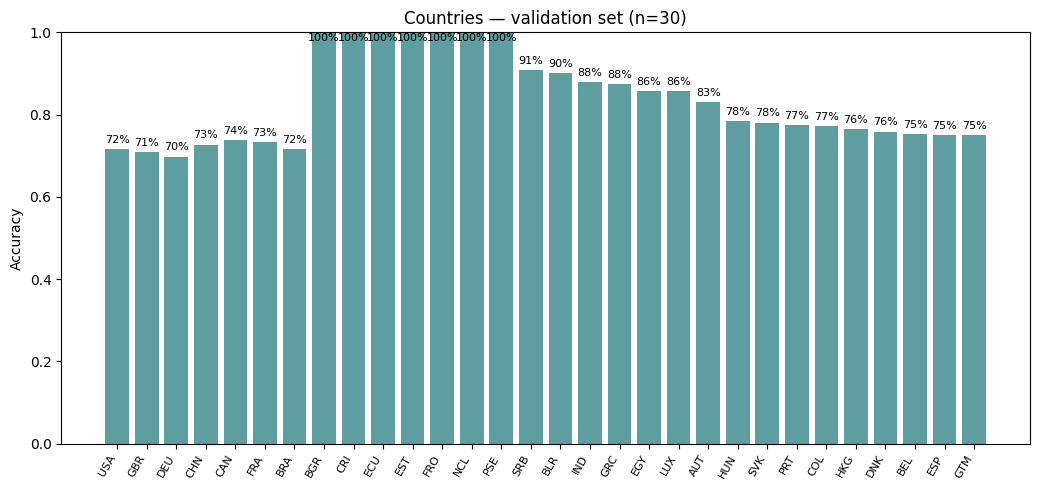

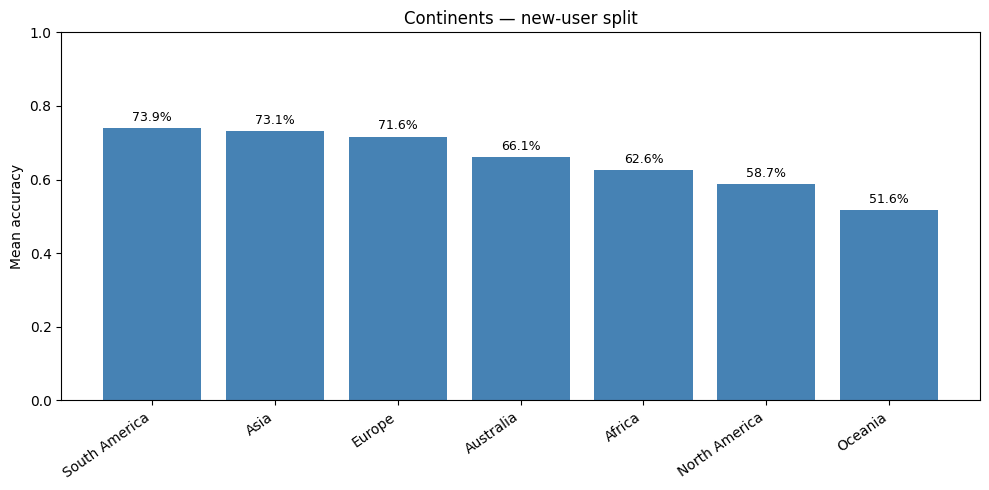

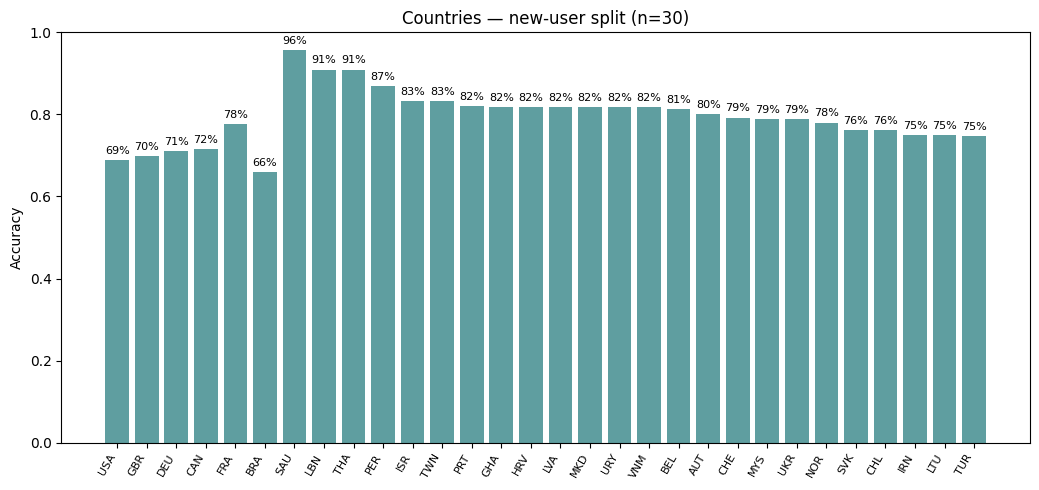

In [11]:
from jury_learning.plots import run_evaluation_plots

run_evaluation_plots(
    cfg,
    result.bundle,
    result.model,
    split_metrics=result.eval_accuracy_by_split,
    history=result.training_history,
)
